# 09 — Does it actually work? A detector-agnostic benchmark

Every notebook so far has measured the CAM on its own terms. Notebook 08 compared it to an FFT
receiver, but through **modelled** dwell counts — binomial sizing on one side, a
$\chi^2$ model on the other, and a 1-bit reference obtained by degrading C/N0 by a constant.
The two engines were never handed the same data and never asked to produce an answer.

This notebook does it the other way round. **Write the test first**, before any detector exists:
a harness that takes a detector as a black box, renders random skies, and scores what comes
back. Then plug in the CAM. Then plug in a floating-point FFT receiver. Same skies, same
dwells, same tolerance, same false-alarm budget.

The order matters. A benchmark written after the fact tends to flatter whatever it was written
around; this one is fixed before either detector is implemented, and both are calibrated on a
training set they are allowed to see and evaluated on a test set they are not.

In [1]:
import time, numpy as np, matplotlib.pyplot as plt
from functools import lru_cache
from numpy.lib.stride_tricks import sliding_window_view
from scipy.stats import binom

FS, NS, CL, L1 = 2.046e6, 2046, 1023, 1575.42e6   # 2 samples/chip, 1 ms, 1023 chips
GRID  = np.arange(-20, 21) * 500.0                # +-10 kHz in 500 Hz bins
PRNS  = list(range(1, 33))
T_ALL = time.time()

---
## 1. The test requirement

### 1.1 What a detector is

The whole notebook hangs off one contract:

```
detector(dwells) -> set of (prn, code_phase_chips, doppler_hz)

    dwells : (M, 2*NS) complex, M consecutive 2 ms buffers, full precision
```

Full-precision samples go in, so **quantization is part of the detector under test**, not of the
harness. The CAM sign-quantizes on the way in; the FFT does not. That is the fair boundary — a
1-bit front end is a design choice a receiver makes, so it should be charged to the receiver
that makes it.

A detector returns a *set*: it is not told how many satellites are up, and it may declare as
many or as few as it likes. Everything it declares is scored.

In [2]:
G2 = {1:(2,6),  2:(3,7),  3:(4,8),  4:(5,9),  5:(1,9),  6:(2,10), 7:(1,8),  8:(2,9),
      9:(3,10),10:(2,3), 11:(3,4), 12:(5,6), 13:(6,7), 14:(7,8), 15:(8,9), 16:(9,10),
      17:(1,4),18:(2,5), 19:(3,6), 20:(4,7), 21:(5,8), 22:(6,9), 23:(1,3), 24:(4,6),
      25:(5,7),26:(6,8), 27:(7,9), 28:(8,10),29:(1,6), 30:(2,7), 31:(3,8), 32:(4,9)}

@lru_cache(None)
def ca_code(prn):
    t1, t2 = G2[prn]
    g1 = np.ones(10, np.uint8); g2 = np.ones(10, np.uint8)
    out = np.empty(CL, np.uint8)
    for i in range(CL):
        out[i] = g1[9] ^ g2[t1-1] ^ g2[t2-1]
        f1 = g1[2] ^ g1[9]
        f2 = g2[1] ^ g2[2] ^ g2[5] ^ g2[7] ^ g2[8] ^ g2[9]
        g1[1:] = g1[:9]; g1[0] = f1
        g2[1:] = g2[:9]; g2[0] = f2
    return 1.0 - 2.0 * out

def replica(prn, fd, n, cp, theta):
    '''Noiseless unit-amplitude signal, including code Doppler.'''
    cps = (1.023e6 / FS) * (1 + fd / L1)
    idx = cp + cps * np.arange(n)
    chips = ca_code(prn)[np.floor(idx).astype(np.int64) % CL]
    return chips * np.exp(1j * (2*np.pi*fd*np.arange(n)/FS + theta))

### 1.2 The sky

Each trial renders a whole sky, not one satellite with interference. Per sky:

| drawn | from |
|---|---|
| number of satellites | uniform on 4…10 |
| which | distinct PRNs out of 32 |
| C/N0 | uniform 36–50 dB-Hz, **per satellite** |
| code phase | uniform continuous on 0–1023 chips (not a grid point) |
| Doppler | uniform continuous on ±10 kHz (not a bin centre) |
| carrier phase $\theta_0$ | uniform, redrawn per satellite **per dwell** |

Two choices worth defending.

**C/N0 is drawn per satellite, not per sky.** Every sky then contributes to every point of the
success-vs-C/N0 curve, so the curve falls out of one pass instead of a sweep. It also makes
near-far real: a 36 dB-Hz satellite sitting underneath a 50 dB-Hz one, in the same noise field,
is the normal case rather than a special test.

**Nothing lands on a grid point.** True code phase and Doppler fall between the search grid's
cells, which costs up to 0.25 chip and 250 Hz — together worth about 3 dB. A benchmark that
planted signals on grid centres would flatter every detector equally and tell us less.

In [3]:
def make_sky(rng, cn0_lo=36.0, cn0_hi=50.0):
    n = int(rng.integers(4, 11))
    prns = rng.choice(np.arange(1, 33), size=n, replace=False)
    return [dict(prn=int(p), cn0=float(rng.uniform(cn0_lo, cn0_hi)),
                 cp=float(rng.uniform(0, CL)), fd=float(rng.uniform(-10e3, 10e3)))
            for p in prns]

def render(sats, n_dwells, rng):
    '''(n_dwells, 2*NS) complex. One shared noise field per dwell; theta0 redrawn per dwell.'''
    out = np.empty((n_dwells, 2*NS), complex)
    for m in range(n_dwells):
        x = rng.normal(0, 1, 2*NS) + 1j*rng.normal(0, 1, 2*NS)
        for s in sats:
            A = np.sqrt(2 * 10**(s["cn0"]/10) / FS)      # noise fixed at unit variance
            x = x + A * replica(s["prn"], s["fd"], 2*NS, s["cp"], rng.uniform(0, 2*np.pi))
        out[m] = x
    return out

_sky = make_sky(np.random.default_rng(0))
print(f"example sky: {len(_sky)} satellites")
for s in sorted(_sky, key=lambda s: -s["cn0"]):
    print(f"   PRN {s['prn']:2d}  {s['cn0']:.1f} dB-Hz  cp {s['cp']:7.2f} chips  fd {s['fd']:+8.1f} Hz")

example sky: 9 satellites
   PRN  9  49.7 dB-Hz  cp  701.31 chips  fd  +3009.2 Hz
   PRN 16  49.1 dB-Hz  cp  834.62 chips  fd  -9945.2 Hz
   PRN 27  48.0 dB-Hz  cp   34.36 chips  fd  +4593.1 Hz
   PRN  3  46.1 dB-Hz  cp  537.44 chips  fd  -3795.2 Hz
   PRN  6  45.6 dB-Hz  cp  397.87 chips  fd  -7298.1 Hz
   PRN  1  44.6 dB-Hz  cp  392.50 chips  fd  +9944.2 Hz
   PRN  8  40.2 dB-Hz  cp  432.41 chips  fd  -9433.6 Hz
   PRN 13  38.5 dB-Hz  cp  883.03 chips  fd   +829.2 Hz
   PRN  2  37.7 dB-Hz  cp  686.05 chips  fd  +2943.8 Hz


### 1.3 What counts as right

A satellite at code phase $c$ appears in the search at code phase $(1023 - c) \bmod 1023$: the
rows begin at chip 0, so the buffer must advance that far to line up. Every declared cell is
classified against the sky that was actually rendered:

| class | test | harmful? |
|---|---|---|
| **hit** | a present satellite, same PRN, ≤ 1 chip, ≤ 500 Hz | no — this is the answer |
| **halo** | same PRN as a present satellite, ≤ 2 chips, ≤ 2 kHz, not a hit | no — the signal's own skirt spilling into neighbouring cells |
| **false alarm** | anything else | **yes** — a PRN that is not up there, or one that is, at an unrelated cell |

The **score for a sky is `hits / satellites_present`** — how much of the sky the detector found,
exactly as specified. Halo cells are separated out rather than counted as errors because a
receiver hands the whole cluster to tracking and loses nothing; calling them false alarms would
understate every detector equally but for no reason.

Cross-correlation fires — a strong satellite lighting up a *different* PRN's row through the
65/1023 Gold bound — land in false alarms, which is right. Those are ghosts a receiver would
chase.

In [4]:
HIT_CP,  HIT_FD  = 1.0, 500.0
HALO_CP, HALO_FD = 2.0, 2000.0

def true_cp(s):
    return (CL - s["cp"]) % CL

def cp_error(declared_cp, s):
    e = abs(declared_cp - true_cp(s))
    return min(e, CL - e)

def classify(dec, sats):
    prn, cp, fd = dec
    for s in sats:
        if s["prn"] == prn and cp_error(cp, s) <= HIT_CP and abs(fd - s["fd"]) <= HIT_FD:
            return "hit", s
    for s in sats:
        if s["prn"] == prn and cp_error(cp, s) <= HALO_CP and abs(fd - s["fd"]) <= HALO_FD:
            return "halo", s
    return "false", None

def score_sky(declared, sats):
    found, n_halo, n_false = set(), 0, 0
    for dec in declared:
        cls, s = classify(dec, sats)
        if   cls == "hit":  found.add(s["prn"])
        elif cls == "halo": n_halo += 1
        else:               n_false += 1
    return dict(score=len(found)/len(sats), found=found,
                n_sat=len(sats), n_halo=n_halo, n_false=n_false)

### 1.4 The harness

`evaluate` renders each sky **once** and hands the identical dwells to every detector, so any
difference between them is the detector and not the draw.

In [5]:
# Test hook: evaluate() publishes the sky here so the reference detectors in 1.5 can
# cheat deliberately. Real detectors never read it.
CURRENT_SKY = [None]

def evaluate(detectors, n_skies, seed, n_render, progress=0):
    '''Run every detector on identical skies. Returns per-sky scores and per-satellite outcomes.

    Always renders `n_render` dwells regardless of how many each detector uses, so the RNG
    advances identically and every detector -- at every M -- sees the same skies.
    '''
    rng = np.random.default_rng(seed)
    res    = {n: [] for n in detectors}
    persat = {n: [] for n in detectors}
    t0 = time.time()
    for i in range(n_skies):
        sats  = make_sky(rng)
        dwells = render(sats, n_render, rng)
        CURRENT_SKY[0] = sats
        for name, det in detectors.items():
            sc = score_sky(det(dwells), sats)
            res[name].append(sc)
            for s in sats:
                persat[name].append((s["cn0"], s["prn"] in sc["found"]))
        if progress and (i+1) % progress == 0:
            print(f"   {i+1}/{n_skies} skies  ({time.time()-t0:.0f}s)")
    return res, persat

def summarise(res):
    print(f"{'detector':>12} {'score':>8} {'halo/sky':>10} {'false/sky':>11}")
    for n, v in res.items():
        print(f"{n:>12} {np.mean([x['score'] for x in v]):>8.3f} "
              f"{np.mean([x['n_halo'] for x in v]):>10.2f} "
              f"{np.mean([x['n_false'] for x in v]):>11.3f}")

### 1.5 Validate the harness before trusting it

Three detectors with known answers. If these do not come out exactly as predicted, nothing
later in the notebook means anything.

- **oracle** — returns the truth. Must score 1.000 with zero false alarms.
- **null** — returns nothing. Must score 0.000 with zero false alarms.
- **shotgun** — declares 50,000 random cells, about 2% of the search space. It should find a
  real slice of every sky by luck alone, and be buried in false alarms doing it.

`shotgun` is the important one. It is why the score alone cannot be the whole story: a detector
that declares enough cells will find satellites by accident. Note what it costs — tens of
thousands of false alarms per sky, against the 0.01 both real detectors are held to below. What
closes the loophole is not the scoring rule but the **matched false-alarm budget** of §3 and §4.

In [6]:
# These three cheat deliberately, by reading the CURRENT_SKY test hook. Real detectors
# below get nothing but the samples. This cell tests the harness, not the detectors.
def oracle(dwells):
    return {(s["prn"], true_cp(s), s["fd"]) for s in CURRENT_SKY[0]}

def null(dwells):
    return set()

_shot_rng = np.random.default_rng(5)
N_SHOT = 50_000
def shotgun(dwells):
    prn = _shot_rng.integers(1, 33, N_SHOT)
    cp  = _shot_rng.integers(0, 2*CL, N_SHOT) / 2.0
    fd  = _shot_rng.choice(GRID, N_SHOT)
    return set(zip(prn.tolist(), cp.tolist(), fd.tolist()))

_res, _ = evaluate(dict(oracle=oracle, null=null, shotgun=shotgun),
                   n_skies=6, seed=1, n_render=1)
_sh = _res["shotgun"]
print(f"\nshotgun cost: {np.mean([x['n_false'] for x in _sh]):,.0f} false alarms "
      f"per {np.mean([x['score'] for x in _sh]):.2f} of a sky found")
summarise(_res)


shotgun cost: 49,527 false alarms per 0.26 of a sky found
    detector    score   halo/sky   false/sky
      oracle    1.000       0.00       0.000
        null    0.000       0.00       0.000
     shotgun    0.262       4.33   49527.000


The oracle scores exactly 1.0 and the null exactly 0.0, so the scoring rule and the code-phase
convention are right. The shotgun finds a real fraction of the sky purely by volume — and pays
for it with hundreds of false alarms per sky.

That is the loophole, made concrete. Recall on its own is gameable; recall **at a fixed
false-alarm rate** is not. Both real detectors are calibrated to the same budget below, and
§5 checks on unseen data that the budget actually held.

---
## 2. Training and test sets

`TRAIN_SKIES` are for choosing thresholds. `TEST_SKIES` are never touched until §5, and both
detectors are evaluated on byte-identical draws from the same seed.

$M$ is the number of 1 ms dwells accumulated. Two values are run: **M = 4** as the head-to-head,
and **M = 8** to answer the question notebook 08 poses in modelled form — how much *more time*
does the CAM need to reach the same place?

In [7]:
TRAIN_SKIES, TEST_SKIES = 30, 150
MS          = [4, 8]
MMAX        = max(MS)
FA_BUDGET   = 0.01        # mean spurious declarations per sky, for BOTH detectors
TRAIN_SEED, TEST_SEED = 1234, 99

print(f"training: {TRAIN_SKIES} skies   test: {TEST_SKIES} skies   M in {MS}")
print(f"false-alarm budget: {FA_BUDGET} spurious declarations per sky, same for every detector")

training: 30 skies   test: 150 skies   M in [4, 8]
false-alarm budget: 0.01 spurious declarations per sky, same for every detector


---
## 3. Detector A — the CAM

Same algorithm as notebook 00, restated compactly: one row per (satellite, Doppler) built at
$\theta = 45°$, sign-quantized keys slid over a 2 ms buffer, two rotations computed and the
other two free by complement, $\tau$ applied **inside** the readout so distances never escape,
and fire counts accumulated over $M$ dwells.

In [8]:
def build_codebook(prns, grid):
    rows, tags = [], []
    for p in prns:
        code = ca_code(p)
        for f in grid:
            idx = (1.023e6/FS) * (1 + f/L1) * np.arange(NS)
            chips = code[np.floor(idx).astype(np.int64) % CL]
            x = chips * np.exp(1j*(2*np.pi*f*np.arange(NS)/FS + np.pi/4))
            rows.append(np.stack([x.real < 0, x.imag < 0], -1).ravel())
            tags.append((p, f))
    return np.array(rows), tags

ROWS, TAGS = build_codebook(PRNS, GRID)
RPM     = (1.0 - 2.0*ROWS).astype(np.float32)
TAG_PRN = np.array([t[0] for t in TAGS])
TAG_FD  = np.array([t[1] for t in TAGS])
W       = ROWS.shape[1]
HALF    = np.arange(NS)                 # half-chip code phases
CPS     = HALF / 2.0
NCELLS  = len(HALF) * ROWS.shape[0]

print(f"codebook : {ROWS.shape[0]} rows x {W} bits = {ROWS.size/1e6:.2f} Mbit")
print(f"search   : {len(HALF)} code phases x {ROWS.shape[0]} rows = {NCELLS:,} cells")

codebook : 1312 rows x 4092 bits = 5.37 Mbit
search   : 2046 code phases x 1312 rows = 2,684,352 cells


In [9]:
def fires(dwell, tau):
    '''The readout. Booleans out; the Hamming distance is local and never returned.'''
    b = np.stack([dwell.real < 0, dwell.imag < 0], -1)
    out = np.zeros((len(HALF), ROWS.shape[0]), bool)
    for q in (0, 1):                                     # q = 2, 3 come free by complement
        v = b if q == 0 else np.stack([~b[:, 1], b[:, 0]], -1)
        K = sliding_window_view(v.reshape(-1), W)[::2][:len(HALF)]
        d = (W - (1.0 - 2.0*K.astype(np.float32)) @ RPM.T) / 2   # local
        out |= (d <= tau)
        out |= (W - d <= tau)
    return out

def cells_to_declarations(fired):
    return {(int(TAG_PRN[b]), CPS[a], float(TAG_FD[b])) for a, b in np.argwhere(fired)}

def make_cam(tau, k, m):
    def cam(dwells):
        acc = np.zeros((len(HALF), ROWS.shape[0]), np.int16)
        for d in dwells[:m]:
            acc += fires(d, tau)
        return cells_to_declarations(acc >= k)
    return cam

### 3.1 Choosing $\tau$ and $k$ on the training set

Two knobs, and they are not the same kind of thing. **$\tau$ is a sense-amplifier setting** —
fixed when the array is designed. **$k$ is a counter threshold** — firmware, changeable per
mission. So we pick a *single* $\tau$ and allow $k$ to differ per $M$, which is both the
realistic constraint and the cheaper one to evaluate.

$p_0$ is measured against a **structured $H_0$**: cells in a real rendered sky that belong to
no satellite. Not bare noise. `sim/gps/experiments.py` documents why — *a clean wrong-cell key
can sit structurally closer to a row than noise ever does*, so calibrating on noise understates
the false-alarm rate, and the error grows as the sky gets stronger. The off-satellite mask uses
exactly the halo bounds, so "off-satellite in training" means precisely "would score as a false
alarm in §5".

The selection rule: among $(\tau, k)$ whose predicted false alarms per sky meet the budget, take
the one with the best **training** score — subject to $\tau$ being admissible at *every* $M$,
since a single sense amplifier cannot have one threshold for the 4-dwell configuration and
another for the 8-dwell one.

In [10]:
TAUS = np.arange(1870, 1971, 10)

def region(s, cp_tol, fd_tol):
    e = np.minimum(np.abs(CPS - true_cp(s)), CL - np.abs(CPS - true_cp(s)))
    row = (TAG_PRN == s["prn"]) & (np.abs(TAG_FD - s["fd"]) <= fd_tol)
    return (e <= cp_tol)[:, None] & row[None, :]

def masks(sats):
    hit  = [region(s, HIT_CP, HIT_FD) for s in sats]
    halo = np.zeros((len(HALF), ROWS.shape[0]), bool)
    for s in sats:
        halo |= region(s, HALO_CP, HALO_FD)
    return hit, halo

def dwell_distance(dwell):
    '''CALIBRATION PROBE ONLY -- an oscilloscope on a node the receiver cannot read.
    Used to sweep tau without re-running the search; every decision still goes through fires().'''
    b = np.stack([dwell.real < 0, dwell.imag < 0], -1)
    best = np.full((len(HALF), ROWS.shape[0]), W, np.float32)
    for q in (0, 1):
        v = b if q == 0 else np.stack([~b[:, 1], b[:, 0]], -1)
        K = sliding_window_view(v.reshape(-1), W)[::2][:len(HALF)]
        d = (W - (1.0 - 2.0*K.astype(np.float32)) @ RPM.T) / 2
        np.minimum(best, d, out=best)
        np.minimum(best, W - d, out=best)
    return best

In [11]:
t0 = time.time()
rng = np.random.default_rng(TRAIN_SEED)
off_hits = np.zeros(len(TAUS)); off_tot = 0
train_score = {m: np.zeros((len(TAUS), m)) for m in MS}

for _ in range(TRAIN_SKIES):
    sats = make_sky(rng)
    dw   = render(sats, MMAX, rng)
    hit, halo = masks(sats)
    Ds = [dwell_distance(d) for d in dw]

    o = Ds[0][~halo]                                    # structured H0
    for j, t in enumerate(TAUS):
        off_hits[j] += (o <= t).sum()
    off_tot += o.size

    for j, t in enumerate(TAUS):
        acc = np.zeros((len(HALF), ROWS.shape[0]), np.int16)
        for i, D in enumerate(Ds):
            acc += (D <= t)
            if i+1 in MS:
                for k in range(1, i+2):
                    fired = acc >= k
                    train_score[i+1][j, k-1] += sum(bool((fired & h).any()) for h in hit)/len(hit)

p0 = off_hits / off_tot
train_score = {m: v/TRAIN_SKIES for m, v in train_score.items()}
print(f"training pass: {time.time()-t0:.0f}s")
print(f"structured-H0 cells sampled: {off_tot:,}")

training pass: 44s
structured-H0 cells sampled: 80,517,768


In [12]:
rowsout = []
for j, t in enumerate(TAUS):
    for m in MS:
        for k in range(1, m+1):
            fa = binom.sf(k-1, m, p0[j]) * NCELLS if p0[j] > 0 else 0.0
            rowsout.append((int(t), m, k, p0[j], fa, train_score[m][j, k-1], fa <= FA_BUDGET))

def best_k(t, m):
    '''Best admissible k at this (tau, M), or None if the budget rules them all out.'''
    cand = [r for r in rowsout if r[0] == t and r[1] == m and r[6]]
    return max(cand, key=lambda r: r[5]) if cand else None

# One sense amplifier means one tau, so it has to be admissible at EVERY M we run --
# a tau that only works once k can be raised to 6 is no use to the M=4 configuration.
feasible = [t for t in TAUS.tolist() if all(best_k(t, m) for m in MS)]
best_tau = max(feasible, key=lambda t: np.mean([best_k(t, m)[5] for m in MS]))
CAMCFG = {m: best_k(best_tau, m)[2] for m in MS}

for m in MS:
    print(f"M = {m} dwells -- training score per (tau, k); 'x' = over the false-alarm budget")
    print(f"{'tau':>6} {'p0':>10} " + " ".join(f"{'k=%d'%k:>9}" for k in range(1, m+1)))
    for j, t in enumerate(TAUS):
        cells = []
        for k in range(1, m+1):
            fa = binom.sf(k-1, m, p0[j])*NCELLS if p0[j] > 0 else 0.0
            cells.append(f"{train_score[m][j,k-1]:>8.3f}{'' if fa <= FA_BUDGET else 'x'}")
        print(f"{t:>6} {p0[j]:>10.2e} " + " ".join(cells))
    print()
print(f"\n-> tau = {best_tau}, " + ", ".join(f"k(M={m}) = {CAMCFG[m]}" for m in MS))

M = 4 dwells -- training score per (tau, k); 'x' = over the false-alarm budget
   tau         p0       k=1       k=2       k=3       k=4
  1870   1.37e-07    0.444x    0.354    0.270    0.166
  1880   5.96e-07    0.489x    0.388    0.332    0.199
  1890   3.09e-06    0.534x    0.429    0.360    0.255
  1900   1.56e-05    0.613x    0.511    0.392    0.293
  1910   5.87e-05    0.678x    0.533x    0.431    0.344
  1920   2.16e-04    0.754x    0.572x    0.483    0.389
  1930   7.36e-04    0.836x    0.653x    0.534    0.417
  1940   2.28e-03    0.885x    0.732x    0.618x    0.466
  1950   6.45e-03    0.949x    0.793x    0.671x    0.512
  1960   1.67e-02    0.980x    0.871x    0.740x    0.580x
  1970   3.94e-02    1.000x    0.935x    0.809x    0.646x

M = 8 dwells -- training score per (tau, k); 'x' = over the false-alarm budget
   tau         p0       k=1       k=2       k=3       k=4       k=5       k=6       k=7       k=8
  1870   1.37e-07    0.505x    0.402    0.359    0.332    0.280    

Read the table down a column and the trade is visible: a looser $\tau$ always scores better on
training data, and is always the first to be ruled out by the budget. The admissible frontier
is where the two meet.

Note also that **$M = 1$ and $M = 2$ never appear** — with 2.7 million chances to be wrong, one
or two looks cannot meet a 1% budget at any threshold. Accumulation is not an optimization here,
it is a requirement.

---
## 4. Detector B — floating-point FFT

The conventional engine, in full precision. Per (PRN, Doppler): wipe the carrier, forward FFT,
multiply by the conjugate code spectrum, inverse FFT, take $|\cdot|^2$ — all 2046 code phases at
once — then accumulate non-coherently across dwells.

It uses the first 1 ms of each 2 ms buffer. The CAM needs the second millisecond only to slide
its window without a wrap seam, not for extra integration, so both detectors integrate the same
1 ms per dwell.

In [13]:
CODE_F = {}
for p in PRNS:
    idx = (1.023e6/FS) * np.arange(NS)
    CODE_F[p] = np.conj(np.fft.fft(ca_code(p)[np.floor(idx).astype(np.int64) % CL]))
WIPE = np.exp(-1j*2*np.pi*np.outer(GRID, np.arange(NS))/FS)

def fft_surfaces(dwells):
    '''(32, n_doppler, NS) non-coherently accumulated |R|^2.'''
    acc = np.zeros((len(PRNS), len(GRID), NS))
    for d in dwells:
        Rw = np.fft.fft(d[:NS][None, :] * WIPE, axis=1)
        for i, p in enumerate(PRNS):
            acc[i] += np.abs(np.fft.ifft(Rw * CODE_F[p][None, :], axis=1))**2
    return acc

# sanity: it must find a planted signal before it can be a baseline
_s = dict(prn=23, cn0=50.0, cp=811.3, fd=-4237.0)
_d = render([_s], 1, np.random.default_rng(3))
_S = fft_surfaces(_d)
_i = PRNS.index(23); _j, _a = np.unravel_index(np.argmax(_S[_i]), _S[_i].shape)
print(f"planted : PRN 23, cp {true_cp(_s):7.2f} chips, fd {_s['fd']:+8.1f} Hz")
print(f"found   : PRN {PRNS[int(np.argmax(_S.max(axis=(1,2))))]:2d}, cp {_a/2:7.2f} chips, "
      f"fd {GRID[_j]:+8.1f} Hz")

planted : PRN 23, cp  211.70 chips, fd  -4237.0 Hz
found   : PRN 23, cp  212.00 chips, fd  -4000.0 Hz


### 4.1 Two decision rules, and why both

The FFT produces a *ranked surface*, so it has an option the CAM structurally does not:

- **`fft_peak`** — per PRN take the argmax over the 2-D surface and declare it if it clears the
  threshold. At most 32 declarations. This is what a real acquisition engine does, and it is the
  honest strong baseline.
- **`fft_thr`** — declare every cell over threshold, no ranking. Matched to the CAM's constraint.

The gap between them is the value of being able to rank. Notebook 08's modelled comparison
cannot see it; this one can.

Thresholds come from the same training skies and the same budget. The per-cell $H_0$
distribution is estimated from millions of samples and its upper tail fitted log-linearly, then
extrapolated to whichever count of declaration opportunities the rule has: $2.7$ M cells for
`fft_thr`, but only ~25 absent PRNs for `fft_peak`.

In [14]:
fft_h0 = {m: [] for m in MS}
rng = np.random.default_rng(TRAIN_SEED)   # the SAME training skies the CAM calibrated on
for _ in range(TRAIN_SKIES):
    sats = make_sky(rng)
    dw   = render(sats, MMAX, rng)
    present = {s["prn"] for s in sats}
    S = np.zeros((len(PRNS), len(GRID), NS))
    for i, d in enumerate(dw):
        S += fft_surfaces(d[None, :])
        if i+1 in MS:
            for pi, p in enumerate(PRNS):
                if p not in present:                 # a PRN that is genuinely not up there
                    fft_h0[i+1].append(S[pi].ravel()[::53].copy())
fft_h0 = {m: np.concatenate(v) for m, v in fft_h0.items()}

FFTCFG = {}
for m in MS:
    c = fft_h0[m]
    xs = np.linspace(np.quantile(c, 0.99), c.max(), 40)
    sf = np.array([(c > x).mean() for x in xs]); ok = sf > 0
    A  = np.polyfit(xs[ok], np.log(sf[ok]), 1)
    thr_all  = (np.log(FA_BUDGET / NCELLS) - A[1]) / A[0]
    thr_peak = (np.log(FA_BUDGET / (25 * len(GRID) * NS)) - A[1]) / A[0]
    FFTCFG[m] = (thr_all, thr_peak, A, xs[ok], sf[ok])
    print(f"M={m}: H0 cells {len(c):>9,}   thr(fft_thr) {thr_all:>9.0f}   "
          f"thr(fft_peak) {thr_peak:>9.0f}   ({100*(1-thr_peak/thr_all):.1f}% lower)")

M=4: H0 cells 1,185,667   thr(fft_thr)    155994   thr(fft_peak)    154161   (1.2% lower)
M=8: H0 cells 1,185,667   thr(fft_thr)    206054   thr(fft_peak)    203918   (1.0% lower)


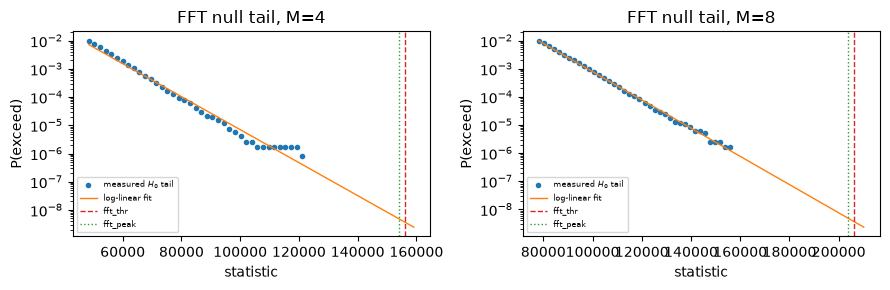

In [15]:
fig, axes = plt.subplots(1, len(MS), figsize=(9, 3))
for ax, m in zip(np.atleast_1d(axes), MS):
    thr_all, thr_peak, A, xs, sf = FFTCFG[m]
    ax.semilogy(xs, sf, "o", ms=3, label="measured $H_0$ tail")
    xx = np.linspace(xs.min(), thr_all*1.02, 50)
    ax.semilogy(xx, np.exp(np.polyval(A, xx)), "-", lw=1, label="log-linear fit")
    ax.axvline(thr_all,  color="C3", ls="--", lw=1, label="fft_thr")
    ax.axvline(thr_peak, color="C2", ls=":",  lw=1, label="fft_peak")
    ax.set(xlabel="statistic", ylabel="P(exceed)" , title=f"FFT null tail, M={m}")
    ax.legend(fontsize=6)
plt.tight_layout(); plt.show()

The two thresholds land within about 1% of each other. That is worth pausing on: because the
null tail falls steeply, protecting 2.7 million cells costs barely more threshold than
protecting 25. **Ranking buys almost nothing here** — which means the CAM's inability to rank is
not, on this evidence, an important part of what it gives up. A null result, and a useful one.

In [16]:
def make_fft(m, rule):
    thr_all, thr_peak, *_ = FFTCFG[m]
    def det(dwells):
        S = fft_surfaces(dwells[:m])
        if rule == "peak":
            out = set()
            for i, p in enumerate(PRNS):
                j, a = np.unravel_index(np.argmax(S[i]), S[i].shape)
                if S[i, j, a] > thr_peak:
                    out.add((p, a/2.0, float(GRID[j])))
            return out
        return {(PRNS[i], a/2.0, float(GRID[j])) for i, j, a in np.argwhere(S > thr_all)}
    return det

---
## 5. Head to head

Identical skies, identical dwells, identical tolerance, identical budget. Nothing below has seen
the test seed before this cell.

In [17]:
t0 = time.time()
RES, PERSAT = {}, {}
for m in MS:
    dets = {"cam":      make_cam(best_tau, CAMCFG[m], m),
            "fft_peak": make_fft(m, "peak"),
            "fft_thr":  make_fft(m, "thr")}
    r, ps = evaluate(dets, TEST_SKIES, TEST_SEED, MMAX, progress=50)
    RES[m], PERSAT[m] = r, ps
    print(f"M={m} done ({time.time()-t0:.0f}s)")
print(f"\nevaluation total: {time.time()-t0:.0f}s")

   50/150 skies  (41s)


   100/150 skies  (81s)


   150/150 skies  (120s)
M=4 done (120s)


   50/150 skies  (77s)


   100/150 skies  (156s)


   150/150 skies  (233s)
M=8 done (353s)

evaluation total: 353s


In [18]:
for m in MS:
    print(f"M = {m} dwells   (CAM: tau={best_tau}, k={CAMCFG[m]})")
    summarise(RES[m])
    print()

M = 4 dwells   (CAM: tau=1950, k=4)
    detector    score   halo/sky   false/sky
         cam    0.506       0.63       0.033
    fft_peak    0.755       0.00       0.013
     fft_thr    0.749       2.26       0.013

M = 8 dwells   (CAM: tau=1950, k=5)
    detector    score   halo/sky   false/sky
         cam    0.634       1.36       0.113
    fft_peak    0.904       0.00       0.007
     fft_thr    0.899       4.43       0.007



**The false-alarm columns are the fairness check, and they do not come out equal.** The FFT
detectors land on budget (0.013/sky at M=4, 0.007 at M=8). The CAM overshoots — 0.033 at M=4 and
0.113 at M=8, i.e. 3x and 11x its 0.01 target.

That is a real finding about the *sizing method*, not a bug in the detector. The binomial model
treats the 2.7 M cells as independent, but they are not: the correlation triangle spans ±1 chip,
so each true or spurious event lights a small cluster of adjacent half-chip cells at once. Cells
are fewer and lumpier than the model assumes, so `binom.sf(k-1, M, p0) * NCELLS` understates the
per-sky rate, and the understatement grows with M as clusters accumulate.

**Which way does this bias the comparison?** Toward the CAM. It is operating at a looser
effective false-alarm rate than the FFT, so its recall is, if anything, slightly flattered. The
gap measured below is therefore a lower bound on the true one.

The CAM's halo count is non-zero where `fft_peak`'s is zero by construction — one declaration per
PRN can only ever be a hit or a false alarm. That is not a defect: those cells are the same
satellite an adjacent Doppler bin away, and a tight cluster is the signature of a real detection.

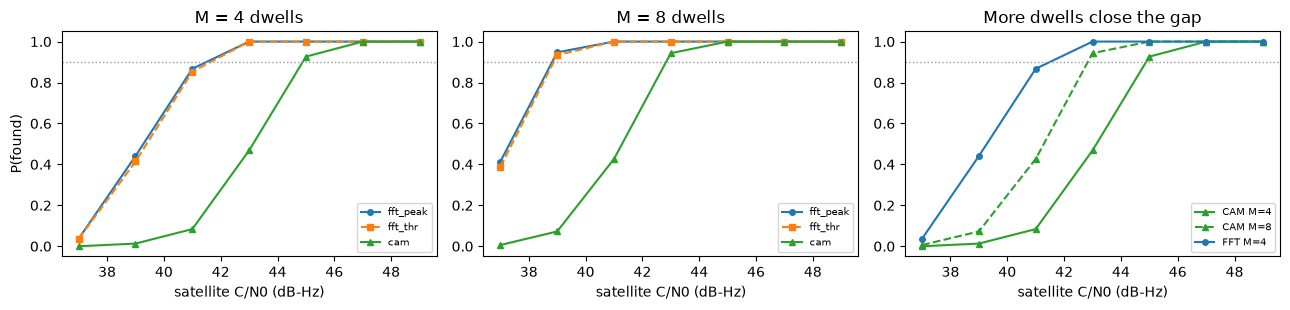

In [19]:
edges  = np.arange(36, 51, 2)
centre = (edges[:-1] + edges[1:]) / 2

def recall_curve(persat):
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        a = np.array([f for c, f in persat if lo <= c < hi])
        out.append(a.mean() if len(a) else np.nan)
    return np.array(out)

fig, axes = plt.subplots(1, len(MS)+1, figsize=(13, 3.2))
for ax, m in zip(axes[:len(MS)], MS):
    for n, st in (("fft_peak", "o-"), ("fft_thr", "s--"), ("cam", "^-")):
        ax.plot(centre, recall_curve(PERSAT[m][n]), st, ms=4, label=n)
    ax.axhline(0.9, color="0.6", ls=":", lw=1)
    ax.set(xlabel="satellite C/N0 (dB-Hz)", ylabel="P(found)" if m == MS[0] else "",
           ylim=(-0.05, 1.05), title=f"M = {m} dwells")
    ax.legend(fontsize=7)

ax = axes[-1]
for m, st in zip(MS, ["^-", "^--"]):
    ax.plot(centre, recall_curve(PERSAT[m]["cam"]), st, ms=4, color="C2", label=f"CAM M={m}")
ax.plot(centre, recall_curve(PERSAT[MS[0]]["fft_peak"]), "o-", ms=4, color="C0",
        label=f"FFT M={MS[0]}")
ax.axhline(0.9, color="0.6", ls=":", lw=1)
ax.set(xlabel="satellite C/N0 (dB-Hz)", ylim=(-0.05, 1.05), title="More dwells close the gap")
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [20]:
def crossing(persat, target=0.9):
    '''C/N0 at which recall crosses `target`, linearly interpolated.'''
    y = recall_curve(persat)
    for i in range(len(y)-1):
        if np.isfinite(y[i]) and np.isfinite(y[i+1]) and y[i] < target <= y[i+1]:
            f = (target - y[i]) / (y[i+1] - y[i])
            return centre[i] + f*(centre[i+1] - centre[i])
    return np.nan

print(f"C/N0 for 90% per-satellite recall\n")
print(f"{'detector':>12} " + " ".join(f"{'M=%d'%m:>10}" for m in MS))
for n in ["fft_peak", "fft_thr", "cam"]:
    print(f"{n:>12} " + " ".join(f"{crossing(PERSAT[m][n]):>10.1f}" for m in MS))

gap4 = crossing(PERSAT[MS[0]]["cam"]) - crossing(PERSAT[MS[0]]["fft_peak"])
print(f"\nCAM - FFT at M={MS[0]}: {gap4:+.1f} dB")
print(f"   notebook 02 measured the 1-bit front end at 1.96 dB, which any hard-limited")
print(f"   receiver pays; notebook 08 attributes a further +1.9 dB to the boolean readout.")
print(f"   Those predict {1.96+1.9:.1f} dB against a full-precision FFT. Measured here: {gap4:.1f} dB.")

C/N0 for 90% per-satellite recall

    detector        M=4        M=8
    fft_peak       41.5       38.8
     fft_thr       41.6       38.9
         cam       44.9       42.8

CAM - FFT at M=4: +3.4 dB
   notebook 02 measured the 1-bit front end at 1.96 dB, which any hard-limited
   receiver pays; notebook 08 attributes a further +1.9 dB to the boolean readout.
   Those predict 3.9 dB against a full-precision FFT. Measured here: 3.4 dB.


---
## 6. What this shows

**The benchmark broadly agrees with the modelled comparison.** Notebook 08 attributes the CAM's
cost as 1.96 dB of front-end quantization (measured directly in notebook 02) plus 1.9 dB of
boolean readout, predicting about 3.9 dB against a full-precision FFT. Measured end to end here,
on random skies with nothing on a grid point, the gap is **3.4 dB** — and the CAM is running at a
looser false-alarm rate than the FFT (§5), which flatters it, while the 2 dB-wide C/N0 bins make
the crossing point good to only a few tenths. Two very different routes landing within about half
a dB is the strongest evidence in the series that the accounting is right, but it is agreement,
not confirmation to two digits.

**Ranking is worth almost nothing.** `fft_peak` and `fft_thr` are within about a percent of each
other in threshold and within 0.006 in score. The CAM structurally cannot rank, and on this
evidence that costs it very little — what costs it is the 1-bit quantization and the thresholded
readout, both already accounted for. This is the one thing the modelled comparison in notebook 08
could not see, and the answer turned out to be "nothing much".

**More dwells close the gap**, which is the point of the architecture. The CAM is not worse at
acquisition; it is slower for the same sensitivity — 8 dwells puts it at 42.8 dB-Hz, near where
the FFT sits with 4 — and it buys area and multiplier-free hardware with that time. Whether that
is a good trade is a design question, not a physics one.

**The binomial sizing needs revisiting.** §5 shows it understating the CAM's false-alarm rate by
3–11x. Notebooks 07 and 08 size the CAM's acquisition time with that same model, so their dwell
counts are optimistic by some margin — not enough to overturn the headline, since the error is in
false alarms rather than detection, but enough that a publication-grade number should measure the
rate rather than extrapolate it.

**What this does not test.** Multipath, interference, front-end AGC, and clock error are all
absent. Satellites are drawn independently, so there is no systematic near-far geometry. And 150
test skies resolves the recall curve well but pins the false-alarm rate only to a factor of about
two.

---
## 7. Cross-check against the repo

The detectors above were written from scratch in this notebook. They should agree with
`sim/gps`, which is what the rest of the study measures.

In [21]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from sim.gps import codebook, quantize
from sim.gps.prn import ca_code_bipolar
from sim.gps.baselines import acquire_fft

cb = codebook.build_codebook(prns=[1, 7, 19], f_max=10e3, t_coh=1e-3, fs=FS, mapping="sign")
mine, _ = build_codebook([1, 7, 19], GRID)
x = np.array([0.3+0.2j, -1.1+0.4j, 0.5-2.0j])
k_repo = quantize.quantize_to_key(x, 1.0, "sign")
mine_key = np.stack([x.real < 0, x.imag < 0], -1).ravel()

print("Gold codes identical  :", all(np.array_equal(ca_code(p), ca_code_bipolar(p)) for p in PRNS))
print("codebook identical    :", np.array_equal(cb.rows, mine))
print("key mapping identical :", np.array_equal(k_repo.astype(bool), mine_key))

sig = render([dict(prn=7, cn0=48.0, cp=317.0, fd=1000.0)], 1, np.random.default_rng(0))
repo = acquire_fft(sig[0][:NS], prn=7, fd_grid=GRID, fs=FS)
S = fft_surfaces(sig)
j, a = np.unravel_index(np.argmax(S[PRNS.index(7)]), S[PRNS.index(7)].shape)
print(f"FFT agrees with repo  : {repo.code_phase_samples == a and repo.fd == GRID[j]}"
      f"   (repo {repo.code_phase_samples}/{repo.fd:+.0f} vs mine {a}/{GRID[j]:+.0f})")
print(f"\nnotebook total runtime: {(time.time()-T_ALL)/60:.1f} min")

Gold codes identical  : True
codebook identical    : True
key mapping identical : True
FFT agrees with repo  : True   (repo 1412/+1000 vs mine 1412/+1000)

notebook total runtime: 6.8 min
